# Module 11: Time-Series Preprocessing for Remote Patient Monitoring (RPM)
## HealthAI 360: Continuous Wearable Sensor Stream Analytics
**Curriculum Track:** Module 11 (Time-Series & Biosensor Streams)  
**Persona:** Professor CodeBreaker  
**Goal:** Clean, align, decompose, and engineer leakage-free temporal features from asynchronous, dropout-prone wearable vital signs streams.

---
### What You Will Learn:
1. **Handling Irregular Timestamps:** Resampling asynchronous IoT packets into an aligned 5-minute equidistant grid.
2. **Missingness Imputation:** Forward-fill vs Linear vs Spline Interpolation for physiologic vitals.
3. **Detrending & Circadian Seasonality:** Isolating 24-hour diurnal biological rhythms from underlying pathophysiologic drift using `seasonal_decompose`.
4. **Temporal Feature Engineering:** Autoregressive lags ($t-1, t-2, t-3$) and rolling window statistics (mean, volatility, min, max).
5. **The Deadly Data Leakage Pitfall:** Why random train-test splitting causes catastrophic failures in production, and how strict chronological windowing guarantees real-world generalization.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from src.timeseries_pipeline.resampler import resample_vitals_stream
from src.timeseries_pipeline.decomposition import decompose_vitals_seasonality
from src.timeseries_pipeline.features import build_temporal_features
from src.timeseries_pipeline.pipeline import run_timeseries_pipeline

print("[Setup] Module 11 time-series modules ready!")

[Setup] Module 11 time-series modules ready!


## 1. Inspecting Asynchronous Wearable Vitals
Notice:
- Time intervals vary between 15 and 45 seconds (irregular packet transmission).
- 8% of packets are missing or dropped due to Bluetooth packet collisions or sensor disconnections.

In [2]:
ts_path = REPO_ROOT / "data" / "timeseries" / "vitals_stream.csv"
df_raw = pd.read_csv(ts_path)
print(f"Total Raw Stream Packets: {len(df_raw):,}")
print(f"Missing Values per Signal:\n{df_raw.isnull().sum()}")
display(df_raw.head())

Total Raw Stream Packets: 5,750
Missing Values per Signal:
timestamp        0
patient_id       0
heart_rate     453
spo2           503
systolic_bp    471
temperature    424
dtype: int64


,timestamp,patient_id,heart_rate,spo2,systolic_bp,temperature
0,2026-10-01 08:00:19.521917061,PAT1001,75.3,96.7,118.9,36.85
1,2026-10-01 08:01:04.415465183,PAT1001,71.0,97.5,121.2,36.72
2,2026-10-01 08:01:22.121104670,PAT1001,75.7,97.7,129.1,NaN
3,2026-10-01 08:02:00.100357649,PAT1001,77.2,97.1,118.7,36.85
4,2026-10-01 08:02:19.260410567,PAT1001,81.5,97.7,128.6,36.81


## 2. Equidistant Resampling & Multi-Method Interpolation
Machine learning models require uniform time intervals $\Delta t$.  
Let's resample to a clean **5-minute grid** and interpolate missing gaps:

In [3]:
df_resampled = resample_vitals_stream(df_raw, freq="5min", method="linear")

print(f"Resampled to 5-min intervals: {len(df_resampled):,} equidistant observations.")
display(df_resampled.head())

Resampled to 5-min intervals: 576 equidistant observations.


,timestamp,heart_rate,spo2,systolic_bp,temperature,patient_id
0,2026-10-01 08:00:00,74.170000,97.490000,121.260000,36.821111,PAT1001
1,2026-10-01 08:05:00,76.211111,97.450000,116.944444,36.859091,PAT1001
2,2026-10-01 08:10:00,77.422222,97.455556,121.144444,36.831250,PAT1001
3,2026-10-01 08:15:00,76.887500,97.412500,122.237500,36.840000,PAT1001
4,2026-10-01 08:20:00,74.940000,97.444444,121.360000,36.853000,PAT1001


## 3. Circadian Seasonality Decomposition
Human vital signs exhibit strong 24-hour diurnal biological rhythms (circadian cycle).  
With 5-minute sampling:
$$\text{Period} = \frac{24 \text{ hours} \times 60 \text{ min/hour}}{5 \text{ min/sample}} = 288 \text{ samples/day}$$

Let's decompose the heart rate stream into:
$$Y(t) = \text{Trend}(t) + \text{Seasonal}(t) + \text{Residual}(t)$$

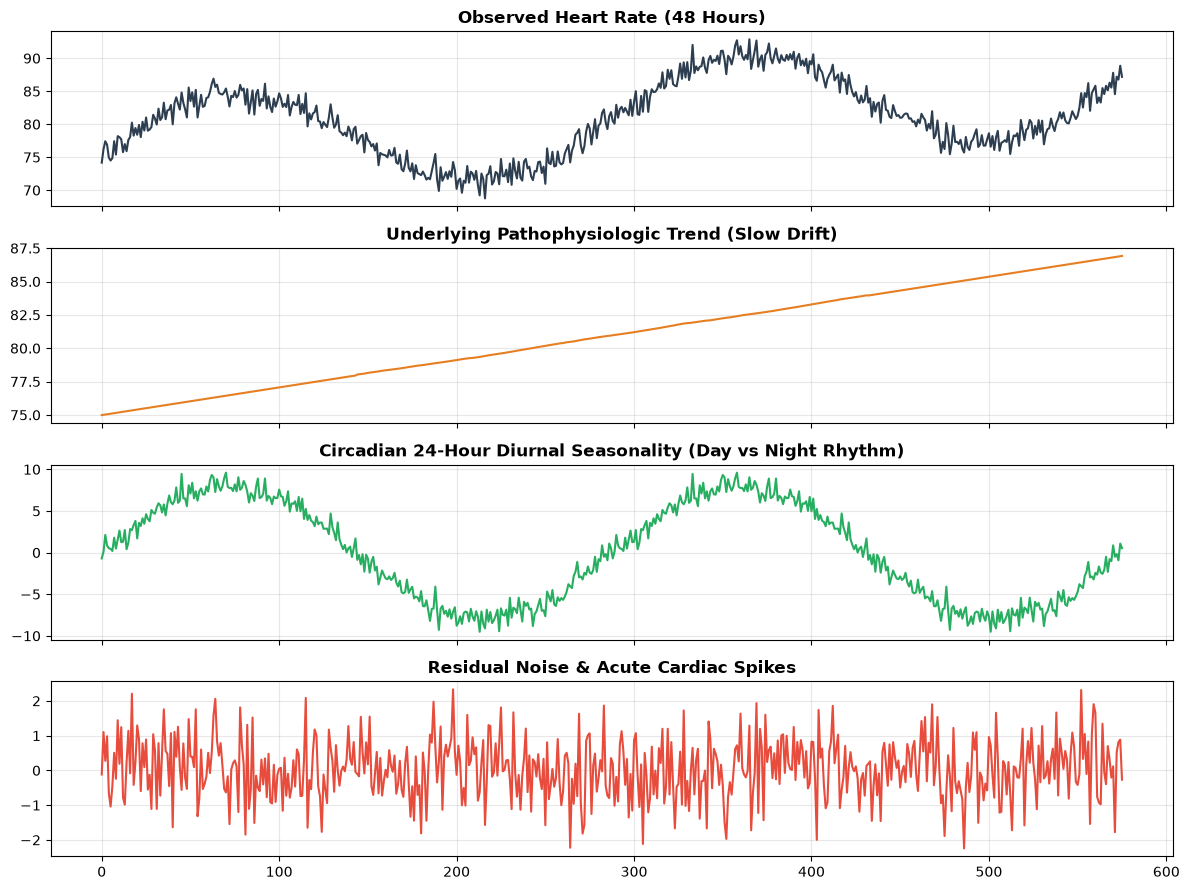

In [4]:
decomp = decompose_vitals_seasonality(df_resampled, col="heart_rate", period=288)

fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
axes[0].plot(df_resampled["heart_rate"], color="#2c3e50")
axes[0].set_title("Observed Heart Rate (48 Hours)", fontweight="bold")
axes[0].grid(True, alpha=0.3)

axes[1].plot(decomp["trend"], color="#e67e22")
axes[1].set_title("Underlying Pathophysiologic Trend (Slow Drift)", fontweight="bold")
axes[1].grid(True, alpha=0.3)

axes[2].plot(decomp["seasonal"], color="#27ae60")
axes[2].set_title("Circadian 24-Hour Diurnal Seasonality (Day vs Night Rhythm)", fontweight="bold")
axes[2].grid(True, alpha=0.3)

axes[3].plot(decomp["residual"], color="#e74c3c")
axes[3].set_title("Residual Noise & Acute Cardiac Spikes", fontweight="bold")
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Avoiding Temporal Data Leakage in Model Evaluation
> **Danger: Random Train-Test Splitting in Time-Series!**  
> If you randomly split time-series observations, observations from $t+1$ and $t-1$ will be in the training set while predicting $t$. Because vital signs are autocorrelated, the model "memorizes the future" and achieves 99% accuracy in testing, but fails completely when deployed live on future patients!
>
> **The Solution:** Strict Chronological Time-based Splitting (Train on past 75%, Evaluate on future 25%). All scalers and rolling windows must be fitted strictly on the past.

Let's run the full pipeline to see the benchmark:

In [5]:
ts_results = run_timeseries_pipeline(str(ts_path))


  [MODULE 11] Running Remote Patient Monitoring Time-Series Pipeline
  Loaded raw vitals stream: 5,750 records with irregular timestamps.


  [Pitfall Demo] Naive Random Split Leakage F1: 0.7740 vs Real Future Split F1: 0.5892
  Step 1: Resampling irregular timestamps to aligned 5-minute grid...
  Step 2: Circadian decomposition (24-hour biological cycle extraction)...
  Step 3: Creating lag features (t-1, t-2, t-3, t-6) and rolling statistics...


  [RESULT] Time-Series Baseline  (Raw irregular point) -> Accuracy: 0.8483 | F1-Macro: 0.5892
  [RESULT] Time-Series Processed (Resampled + Lags)    -> Accuracy: 0.9149 | F1-Macro: 0.6024 (Delta: +0.0133)
